In [3]:
from pyspark.sql import SparkSession

# Membuat SparkSession — "local[*]" berarti gunakan seluruh core CPU yang tersedia di VM
spark = SparkSession.builder \
    .appName("Pertemuan4-PengenalanPySpark") \
    .master("local[*]") \
    .getOrCreate()

# Mengurangi banyaknya pesan log teknis agar output lebih bersih
spark.sparkContext.setLogLevel("ERROR")

print("SparkSession berhasil dibuat!")
print("Versi Spark:", spark.version)

SparkSession berhasil dibuat!
Versi Spark: 3.5.9


In [6]:
# Membuat ulang dataset contoh (identik dengan Tugas Mandiri Pertemuan 2) jika belum ada
import os
if not os.path.exists("data_transaksi_ecommerce.csv"):
    import numpy as np
    import pandas as pd
    np.random.seed(42)
    n = 600
    kategori_list = ["Elektronik", "Fashion", "Makanan & Minuman", "Kesehatan & Kecantikan", "Rumah Tangga"]
    kota_list = ["Magelang", "Yogyakarta", "Semarang", "Solo", "Purworejo"]
    metode_bayar_list = ["Transfer Bank", "E-Wallet", "COD", "Kartu Kredit"]
    tanggal_range = pd.date_range("2026-07-01", "2026-07-31", freq="D")
    data = {
        "order_id": [f"ORD-{1000+i}" for i in range(n)],
        "tanggal": np.random.choice(tanggal_range, size=n).astype(str),
        "kategori": np.random.choice(kategori_list, size=n, p=[0.25,0.25,0.20,0.15,0.15]),
        "kota": np.random.choice(kota_list, size=n),
        "unit_terjual": np.random.randint(1, 10, size=n),
        "harga_satuan": np.random.choice([25000,50000,75000,100000,150000,250000,500000], size=n),
        "metode_pembayaran": np.random.choice(metode_bayar_list, size=n, p=[0.35,0.30,0.20,0.15]),
    }
    pd.DataFrame(data).to_csv("data_transaksi_ecommerce.csv", index=False)
    print("Dataset dibuat ulang.")
else:
    print("Dataset sudah tersedia.")

Dataset sudah tersedia.


In [7]:
# Membaca berkas CSV lokal menjadi Spark DataFrame
df = spark.read.csv("data_transaksi_ecommerce.csv", header=True, inferSchema=True)

print("Tipe objek:", type(df))
df.printSchema()

Tipe objek: <class 'pyspark.sql.dataframe.DataFrame'>
root
 |-- order_id: string (nullable = true)
 |-- tanggal: timestamp (nullable = true)
 |-- kategori: string (nullable = true)
 |-- kota: string (nullable = true)
 |-- unit_terjual: integer (nullable = true)
 |-- harga_satuan: integer (nullable = true)
 |-- metode_pembayaran: string (nullable = true)



In [8]:
# Menampilkan beberapa baris pertama — mirip df.head() di pandas
df.show(5)

# Menghitung jumlah baris — mirip len(df) di pandas
print("Jumlah baris:", df.count())

+--------+-------------------+--------------------+----------+------------+------------+-----------------+
|order_id|            tanggal|            kategori|      kota|unit_terjual|harga_satuan|metode_pembayaran|
+--------+-------------------+--------------------+----------+------------+------------+-----------------+
|ORD-1000|2026-07-07 00:00:00|Kesehatan & Kecan...|  Magelang|           9|      250000|         E-Wallet|
|ORD-1001|2026-07-20 00:00:00|   Makanan & Minuman|Yogyakarta|           9|       50000|     Kartu Kredit|
|ORD-1002|2026-07-29 00:00:00|             Fashion| Purworejo|           2|       50000|     Kartu Kredit|
|ORD-1003|2026-07-15 00:00:00|          Elektronik|      Solo|           3|       50000|         E-Wallet|
|ORD-1004|2026-07-11 00:00:00|          Elektronik|  Semarang|           5|      250000|    Transfer Bank|
+--------+-------------------+--------------------+----------+------------+------------+-----------------+
only showing top 5 rows

Jumlah baris

In [9]:
df.select("order_id", "kota", "kategori").show(5)

+--------+----------+--------------------+
|order_id|      kota|            kategori|
+--------+----------+--------------------+
|ORD-1000|  Magelang|Kesehatan & Kecan...|
|ORD-1001|Yogyakarta|   Makanan & Minuman|
|ORD-1002| Purworejo|             Fashion|
|ORD-1003|      Solo|          Elektronik|
|ORD-1004|  Semarang|          Elektronik|
+--------+----------+--------------------+
only showing top 5 rows



In [10]:
from pyspark.sql.functions import col

# Menyaring transaksi kategori Elektronik dengan unit_terjual lebih dari 5
df.filter((col("kategori") == "Elektronik") & (col("unit_terjual") > 5)).show(5)

+--------+-------------------+----------+----------+------------+------------+-----------------+
|order_id|            tanggal|  kategori|      kota|unit_terjual|harga_satuan|metode_pembayaran|
+--------+-------------------+----------+----------+------------+------------+-----------------+
|ORD-1019|2026-07-03 00:00:00|Elektronik|  Magelang|           9|       75000|         E-Wallet|
|ORD-1020|2026-07-22 00:00:00|Elektronik|  Semarang|           6|      150000|     Kartu Kredit|
|ORD-1028|2026-07-28 00:00:00|Elektronik|  Semarang|           8|      250000|    Transfer Bank|
|ORD-1040|2026-07-31 00:00:00|Elektronik| Purworejo|           6|      100000|         E-Wallet|
|ORD-1054|2026-07-25 00:00:00|Elektronik|Yogyakarta|           9|      500000|    Transfer Bank|
+--------+-------------------+----------+----------+------------+------------+-----------------+
only showing top 5 rows



In [11]:
from pyspark.sql.functions import sum as spark_sum, count, avg

# Menambahkan kolom baru: total_pendapatan = unit_terjual x harga_satuan
df = df.withColumn("total_pendapatan", col("unit_terjual") * col("harga_satuan"))

# Meringkas: total pendapatan & jumlah transaksi per kota, diurutkan dari tertinggi
ringkasan_kota = df.groupBy("kota").agg(
    spark_sum("total_pendapatan").alias("total_pendapatan"),
    count("order_id").alias("jumlah_transaksi"),
    avg("unit_terjual").alias("rata_rata_unit")
).orderBy(col("total_pendapatan").desc())

ringkasan_kota.show()

+----------+----------------+----------------+-----------------+
|      kota|total_pendapatan|jumlah_transaksi|   rata_rata_unit|
+----------+----------------+----------------+-----------------+
|  Magelang|       109925000|             119| 5.07563025210084|
| Purworejo|       104675000|             122|4.737704918032787|
|Yogyakarta|       104625000|             129|5.248062015503876|
|  Semarang|        87200000|             118|4.771186440677966|
|      Solo|        83950000|             112|5.053571428571429|
+----------+----------------+----------------+-----------------+



/tmp/ipykernel_11868/1563172192.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pandas, x='kota', y='total_pendapatan', palette='magma')


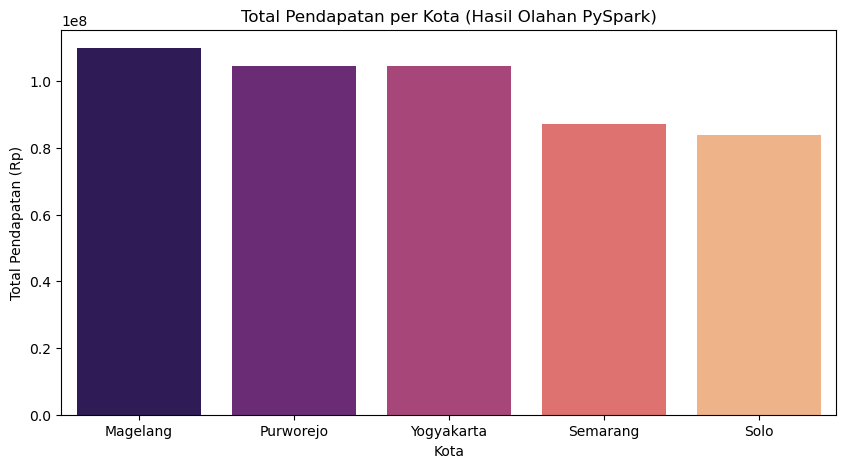

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mengubah objek PySpark DataFrame menjadi Pandas DataFrame
df_pandas = ringkasan_kota.toPandas()

# Membuat Bar Chart menggunakan Seaborn
plt.figure(figsize=(10, 5))
sns.barplot(data=df_pandas, x='kota', y='total_pendapatan', palette='magma')
plt.title('Total Pendapatan per Kota (Hasil Olahan PySpark)')
plt.xlabel('Kota')
plt.ylabel('Total Pendapatan (Rp)')
plt.show()

In [15]:
# Membuat tabel pivot: baris = kota, kolom = kategori, nilai = sum(total_pendapatan)
pivot_df = df.groupBy("kota").pivot("kategori").sum("total_pendapatan")

# Menampilkan hasil pivot table
print("Pivot Table Total Pendapatan (Kota vs Kategori):")
pivot_df.show()

Pivot Table Total Pendapatan (Kota vs Kategori):
+----------+----------+--------+----------------------+-----------------+------------+
|      kota|Elektronik| Fashion|Kesehatan & Kecantikan|Makanan & Minuman|Rumah Tangga|
+----------+----------+--------+----------------------+-----------------+------------+
|  Magelang|  18350000|18825000|              24425000|         25625000|    22700000|
|  Semarang|  30575000|19600000|              13700000|         10300000|    13025000|
|      Solo|  24850000|24925000|               9800000|         15850000|     8525000|
| Purworejo|  10350000|33850000|              22400000|         18550000|    19525000|
|Yogyakarta|  26475000|27625000|              11875000|         25075000|    13575000|
+----------+----------+--------+----------------------+-----------------+------------+



In [16]:
# Mencari transaksi tertinggi yang metode bayarnya E-Wallet ATAU Kartu Kredit
transaksi_pilihan = df.filter(col("metode_pembayaran").isin("E-Wallet", "Kartu Kredit")) \
                      .orderBy(col("total_pendapatan").desc())

transaksi_pilihan.select("order_id", "metode_pembayaran", "total_pendapatan").show(5)

+--------+-----------------+----------------+
|order_id|metode_pembayaran|total_pendapatan|
+--------+-----------------+----------------+
|ORD-1452|     Kartu Kredit|         4500000|
|ORD-1592|         E-Wallet|         4500000|
|ORD-1017|         E-Wallet|         4000000|
|ORD-1260|         E-Wallet|         4000000|
|ORD-1388|         E-Wallet|         4000000|
+--------+-----------------+----------------+
only showing top 5 rows



In [17]:
# Upload dataset ke HDFS terlebih dahulu (jika belum ada dari Pertemuan 3)
!hdfs dfs -mkdir -p /user/mahasiswa/pertemuan4
!hdfs dfs -put -f data_transaksi_ecommerce.csv /user/mahasiswa/pertemuan4/

# Membaca CSV LANGSUNG dari HDFS menggunakan Spark — perhatikan prefix "hdfs://"
df_dari_hdfs = spark.read.csv(
    "hdfs://localhost:9000/user/mahasiswa/pertemuan4/data_transaksi_ecommerce.csv",
    header=True, inferSchema=True
)
print("Jumlah baris dari HDFS:", df_dari_hdfs.count())
df_dari_hdfs.show(5)

Jumlah baris dari HDFS: 600
+--------+-------------------+--------------------+----------+------------+------------+-----------------+
|order_id|            tanggal|            kategori|      kota|unit_terjual|harga_satuan|metode_pembayaran|
+--------+-------------------+--------------------+----------+------------+------------+-----------------+
|ORD-1000|2026-07-07 00:00:00|Kesehatan & Kecan...|  Magelang|           9|      250000|         E-Wallet|
|ORD-1001|2026-07-20 00:00:00|   Makanan & Minuman|Yogyakarta|           9|       50000|     Kartu Kredit|
|ORD-1002|2026-07-29 00:00:00|             Fashion| Purworejo|           2|       50000|     Kartu Kredit|
|ORD-1003|2026-07-15 00:00:00|          Elektronik|      Solo|           3|       50000|         E-Wallet|
|ORD-1004|2026-07-11 00:00:00|          Elektronik|  Semarang|           5|      250000|    Transfer Bank|
+--------+-------------------+--------------------+----------+------------+------------+-----------------+
only show

In [18]:
spark.stop()
print("SparkSession ditutup.")

SparkSession ditutup.
